<a href="https://colab.research.google.com/github/Cav1on/ml-playground/blob/main/06_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7: Convolutional Neural Network(CNN)
Objective: To understand the principles of convolutional networks for image processing.
Tasks:
1. Download the MNIST dataset(handwritten digits).
2. Write the CNN(Convolutional Neural Network) architecture.
3. train the model, save metrics and plot loss/accuracy plots.
4. Visually inspect the prediction results.

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transformation: Convering an image to a tensor and normalizing pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # For black and white images(1 channel)
])

# Download the training and test samples
train_dataset = torchvision.datasets.MNIST(root = './data', train = True, download = True, transform = transform)
test_dataset = torchvision.datasets.MNIST(root = './data', train = False, download = True, transform = transform)

# Create a DataLoader(64 image at a time)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

print(f"Educationa pictures: {len(train_dataset)}")
print(f"Test pictures: {len(test_dataset)}")

Educationa pictures: 60000
Test pictures: 10000


In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN, self).__init__()
    # The first convolutional layer(takes in 1 black and white channel, outputs 16 filters)
    self.conv1 = nn.Conv2d(in_channels = 1, out_channels = 16, kernel_size = 3, padding = 1)
    # Second convolutional layer
    self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, padding = 1)
    # Image reduction layer(takes the maximum from a 2x2 square)
    self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
    # Fully connected layer(10-digit classifier: 0 to 9)
    self.fc1 = nn.Linear(32 * 7 * 7, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x))) # Collapse -> Activate -> Reduce
    x = self.pool(F.relu(self.conv2(x))) # Collapse -> Activate -> Reduce
    x = x.view(-1, 32 * 7 * 7)           # We stretch the image into a flat line
    x = self.fc1(x)                      # Classify
    return x

model = SimpleCNN()
print("The model has been created!")

The model has been created!


In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # Standard for classification into several classes
optimizer = optim.Adam(model.parameters(), lr = 0.001)

epochs = 3
history_loss = []
history_acc = []

print("Let's start training...")
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for images, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    # We consider the accuracy
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  epoch_loss = running_loss / len(train_loader)
  epoch_acc = correct / total
  history_loss.append(epoch_loss)
  history_acc.append(epoch_acc)

  print(f"Epoch {epoch + 1} / {epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

Let's start training...
Epoch 1 / 3 | Loss: 0.2029 | Accuracy: 0.9423
Epoch 2 / 3 | Loss: 0.0609 | Accuracy: 0.9811
Epoch 3 / 3 | Loss: 0.0445 | Accuracy: 0.9862


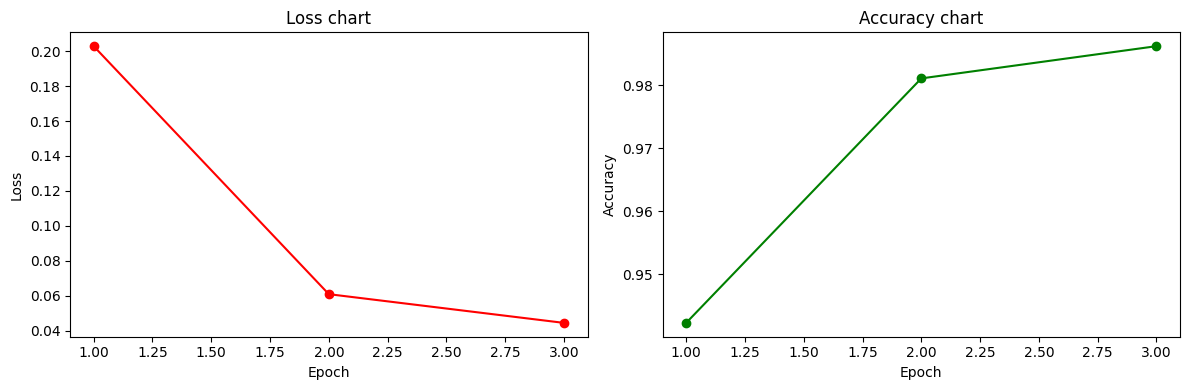

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 4))

# Loss chart
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history_loss, marker = 'o', color = 'red')
plt.title('Loss chart')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Accuracy chart
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), history_acc, marker='o', color='green')
plt.title('Accuracy chart')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

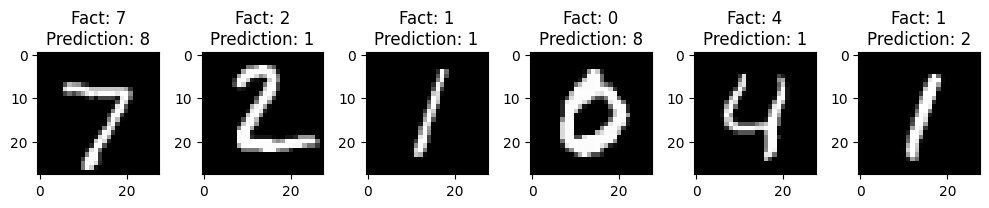

In [12]:
# We take one bathc of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Making a prediction
model.eval()
outputs = model(images)
_, perdicted = torch.max(outputs, 1)

# Let's draw the first 6 pictures
plt.figure(figsize = (10, 4))
for i in range(6):
  plt.subplot(1, 6, i + 1)
  # Returning the iage to normal(getting rid of normalization)
  img = images[i].numpy().squeeze()
  plt.imshow(img, cmap = 'gray')
  plt.title(f"Fact: {labels[i]}\nPrediction: {predicted[i]}")
plt.tight_layout()
plt.show()